# Tree-Based Modeling & Threshold Tuning – AI4I Predictive Maintenance

This notebook trains a Random Forest classifier to predict machine failures, evaluates its performance compared to the Logistic Regression baseline, and explores threshold tuning to prioritize recall. Feature importance is analyzed to understand which mechanical indicators contribute most to failure prediction.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/ai4i2020.csv")

# Select features and target
features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]
X = df[features]
y = df["Machine failure"]

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Tree-Based Model – Random Forest

Random Forest is a nonlinear classification model that predicts machine failure (0 or 1) by combining multiple decision trees.  
Instead of a single linear equation, it uses many trees to capture complex patterns and interactions between features.

This model was chosen after the Logistic Regression baseline because:
- It can capture nonlinear relationships that Logistic Regression misses.
- It handles class imbalance with `class_weight="balanced"`.
- It outputs probability scores for threshold tuning, not just hard predictions.
- It provides feature importance, helping us understand which variables drive failures.
- It serves as a strong benchmark for operational predictive maintenance models.

## Feature Scaling

Random Forest is not sensitive to feature magnitudes, so the model can use the raw features directly. Scaling is mainly required for models that rely on distance or margin geometry, such as SVMs or k‑NN—not Logistic Regression

In [2]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Model Predictions

- `y_pred` gives the model’s predicted class labels (0 = no failure, 1 = failure).  
- `y_prob` gives the predicted probability of failure for each machine.  
- Probabilities allow adjusting the decision threshold instead of relying only on the default 0.5, which is useful to increase recall for rare failures.

In [3]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

In [4]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)
print("\nROC-AUC Score:", roc_auc)

Confusion Matrix:
[[1927    5]
 [  29   39]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.89      0.57      0.70        68

    accuracy                           0.98      2000
   macro avg       0.94      0.79      0.84      2000
weighted avg       0.98      0.98      0.98      2000


ROC-AUC Score: 0.9619793569601754


## Threshold Tuning

The default probability threshold for classification is 0.5.  
Since missing failures is costly, we can lower the threshold to classify machines as failures more aggressively.  
Here a threshold of 0.3 is used as an example to increase recall.

In [ ]:
threshold = 0.3
y_pred_threshold = (y_prob >= threshold).astype(int)

# Evaluate new predictions
print("Confusion Matrix at threshold 0.3:")
print(confusion_matrix(y_test, y_pred_threshold))
print("\nClassification Report at threshold 0.3:")
print(classification_report(y_test, y_pred_threshold))

Confusion Matrix at threshold 0.3:
[[1914   18]
 [  17   51]]

Classification Report at threshold 0.3:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.74      0.75      0.74        68

    accuracy                           0.98      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.98      0.98      0.98      2000


ROC-AUC Score:
0.8703416149068324


## Confusion Matrix Interpretation

1914 → True Negatives  
18    → False Positives  
17   → False Negatives  
51   → True Positives  

The model correctly identified 51 out of 68 actual failures (recall = 0.75), but missed 17 failures.  

Only 18 machines were incorrectly flagged as failures, giving high precision (0.74) for the failure class.

Overall accuracy is 0.98, but this metric is influenced by class imbalance and is not the primary focus.

The ROC-AUC score of 0.87 indicates excellent overall separation between failure and non-failure classes.

## Feature Importance

Random Forest provides a measure of feature importance.  
This shows which features contribute most to predicting failures and aligns with domain knowledge from EDA.

,Feature,Importance
3,Torque [Nm],0.321486
2,Rotational speed [rpm],0.312385
4,Tool wear [min],0.218784
0,Air temperature [K],0.090874
1,Process temperature [K],0.056471


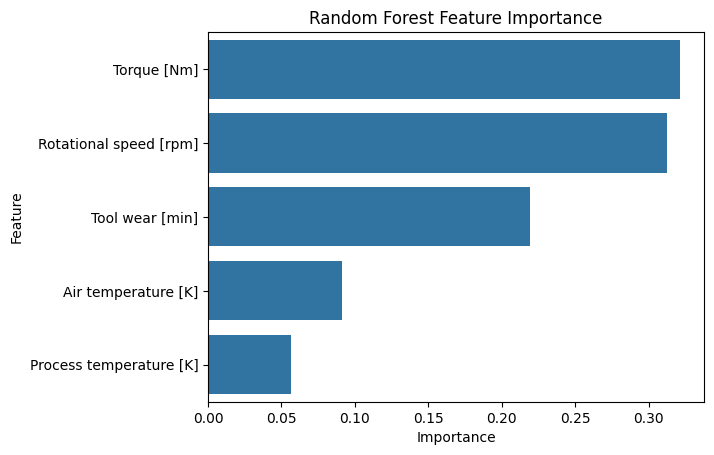

In [6]:
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display table
display(feature_importance_df)

# Plot
sns.barplot(data=feature_importance_df, x='Importance', y='Feature')
plt.title("Random Forest Feature Importance")
plt.show()

## Model Evaluation Summary

- Random Forest improves recall for the rare failure class compared to Logistic Regression.
- Confusion matrix shows how many failures were correctly detected (True Positives) and missed (False Negatives).
- ROC-AUC of ~0.87 indicates strong overall class separation.
- Lowering the classification threshold increases recall, but also raises false positives.
- Feature importance confirms torque and tool wear are the strongest predictors of failure.
- This serves as a benchmark for hyperparameter tuning or ensemble models.